In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

from utils.heatpipe_utils import generate_cfgs_seq, generate_cfg, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

import utils.sodium_properties as s_props

%config InlineBackend.figure_format = "retina"

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [26]:
with open("data/vapour_data.json", "r") as f:
    exp_data = json.load(f) 
    data_560  = exp_data["data_guoju_560"]
    data_560["material"]["h_cond"] = 59.2

In [27]:
Ns = [[45, 50], [45, 50]]
Qs = [data_560["bc"]["Q"] for i in range(len(Ns))]
cfgs = generate_cfgs_seq(data_560, Ns, Qs)

heatpipes = [Heatpipe(cfg) for cfg in cfgs]

heatpipes[-1].set_variable_k(True)

solver = Solver(heatpipes)
solver.fsolve()

Mesh warning: N_R changed from 45 to 48
Mesh warning: N_R changed from 45 to 48
Running case 1 ...
fsolve message: The solution converged.
Running case 2 ...
fsolve message: The solution converged.


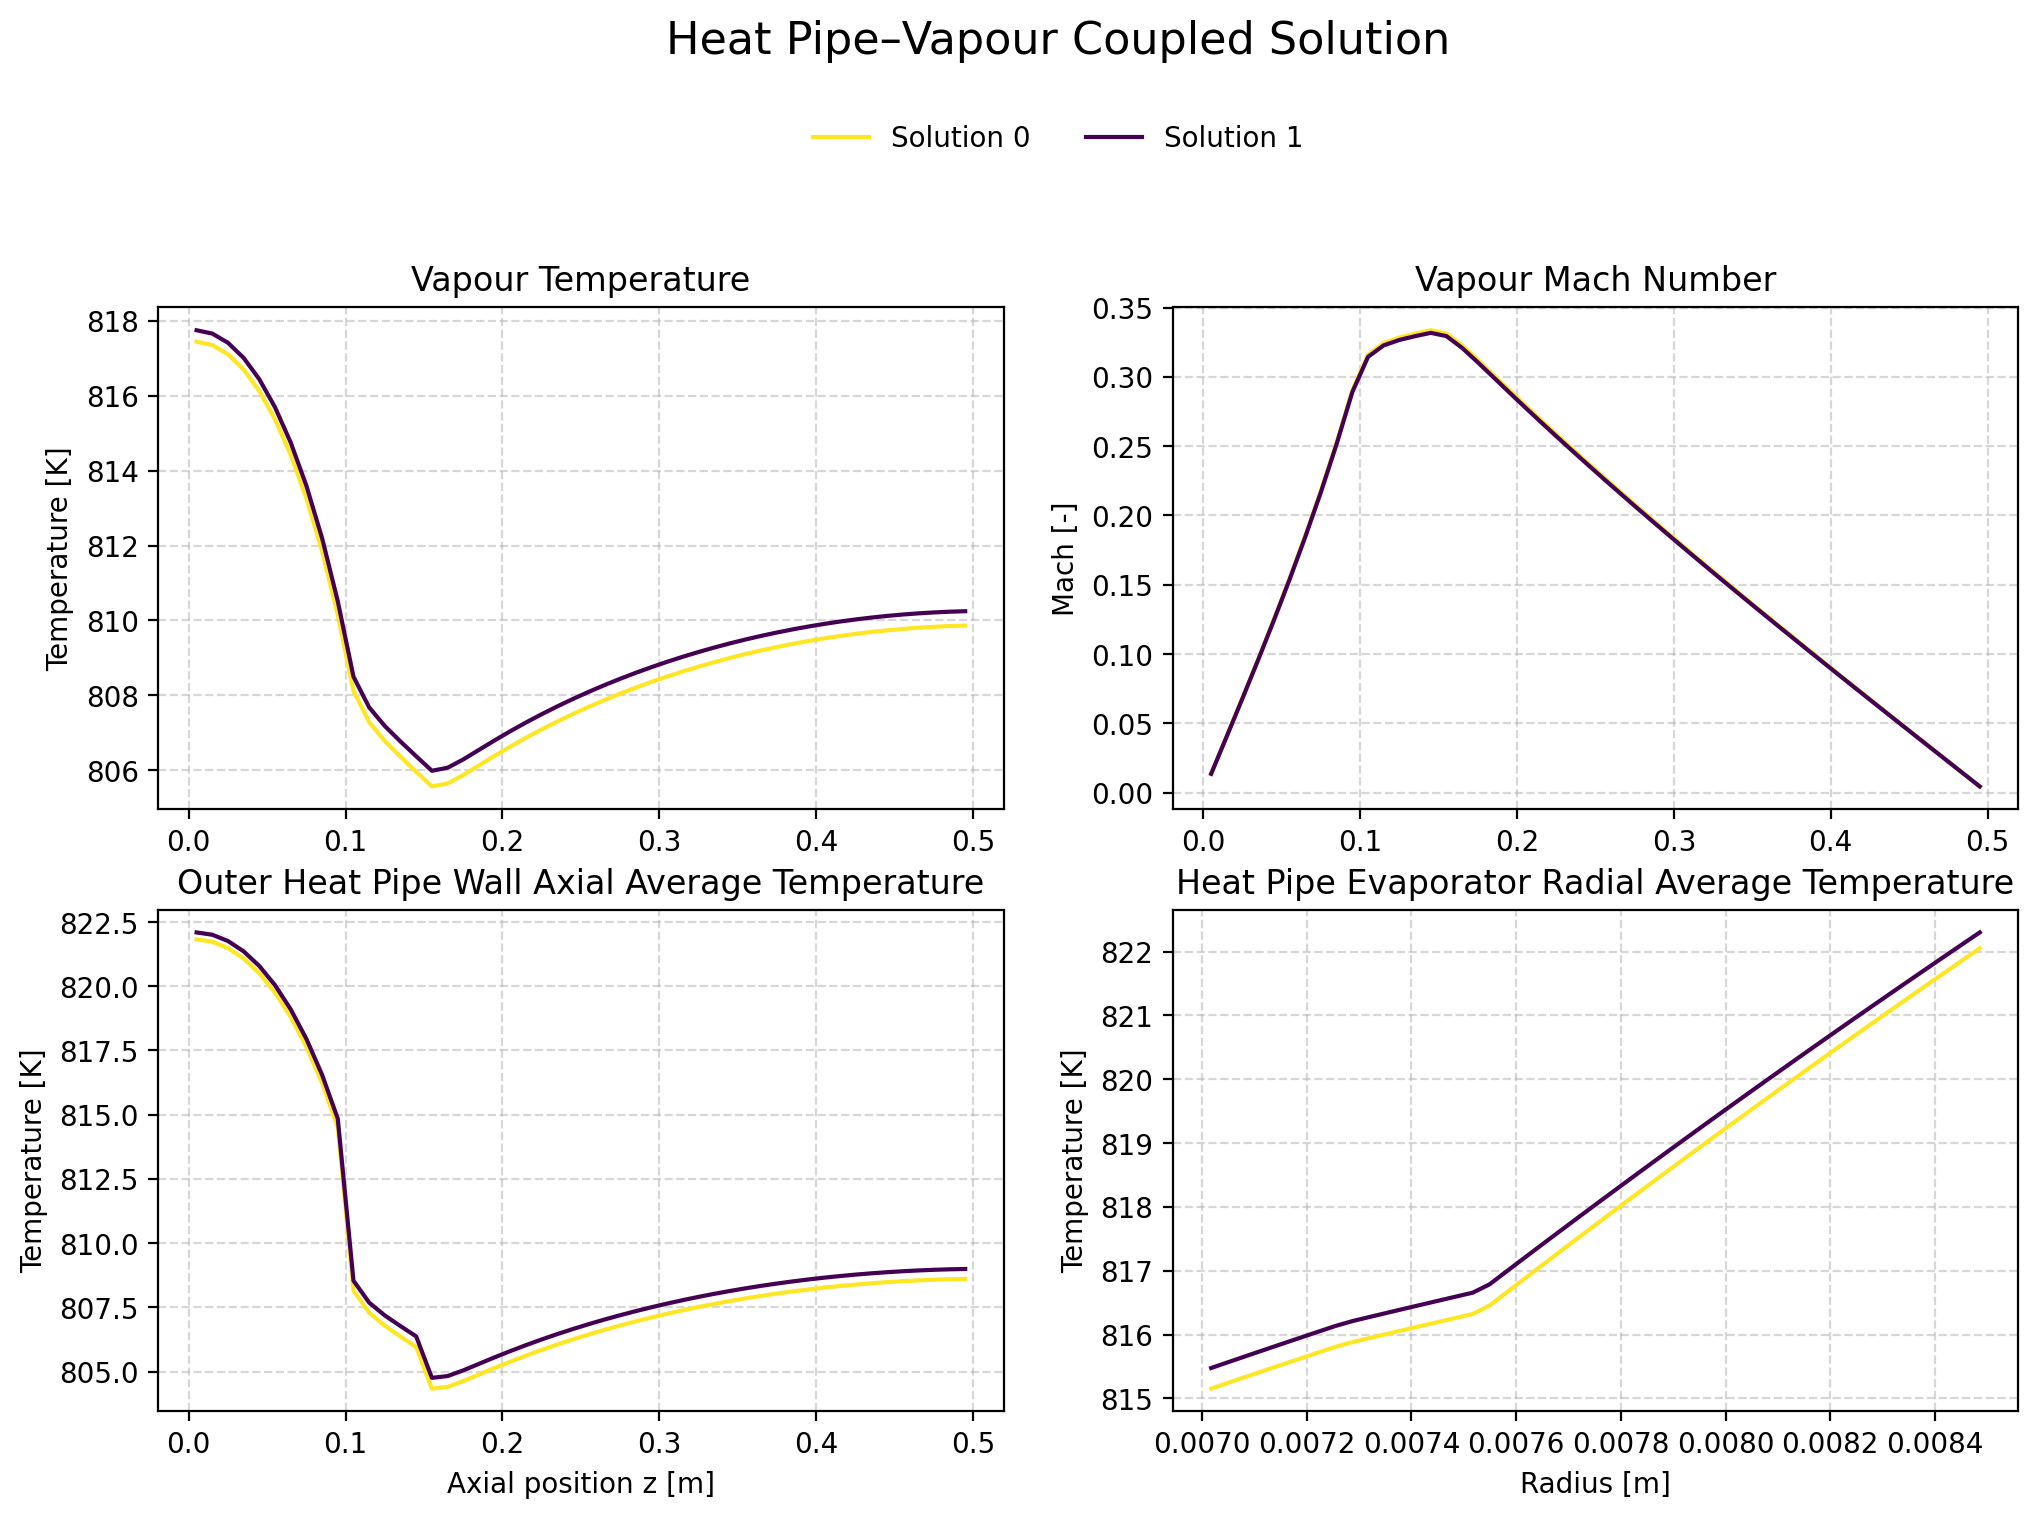

In [28]:
plot_heatpipe_solutions(solver)